# FASE 3: Stacking Ensemble

Berdasarkan Metode 3 dari literatur **Han et al. (2021)**, pendekatan *Stacking Ensemble* dapat membantu meningkatkan performa pada sampel kecil, dengan catatan bahwa model-model pembentuknya (kandidat learner) memiliki prediksi yang saling berbeda (berkorelasi rendah).

**Alur yang diterapkan di notebook ini:**
1. **Candidate Learners**: Menggunakan `RandomForest` (non-linear, pohon keputusan), `LogisticRegression` (linear), dan `SVM` (margin-based). Semuanya dijalankan dengan parameter `class_weight='balanced'`.
2. **Inner CV**: Menggunakan $10$-Fold untuk menghasilkan prediksi probabilitas mandiri (*Out-Of-Fold*).
3. **Meta-Learner**: Menggunakan `LogisticRegression` sebagai agregator final untuk menggabungkan prediksi kandidat.
4. **Outer CV**: Menggunakan *Repeated Stratified 5-Fold* untuk evaluasi performa *stacking* (diulangi hingga puluhan/ratusan kali untuk stabilitas).

*Catatan: Semua proses tetap dibungkus dalam `Pipeline` yang dilengkapi teknik Variable Screening (Lasso) yang terbukti ampuh dari Fase 2.*

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import make_scorer, matthews_corrcoef

from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel

# 1. Setup paths & Data
BASE_DIR = Path.cwd().parent.resolve()
DATA_PATH = str(BASE_DIR / 'data' / 'umkm_success.csv')
RESULTS_PATH = str(BASE_DIR / 'results')

df = pd.read_csv(DATA_PATH)
df_dropped = df.drop(columns=['Age', 'Owner_Gender'])
X = df_dropped.drop(columns=['Success'])
y = df_dropped['Success']

mcc_scorer = make_scorer(matthews_corrcoef)
print("Data loaded. X shape:", X.shape)

Data loaded. X shape: (250, 10)


## 1. Membangun Arsitektur Stacking & Evaluasi

In [2]:
# Candidate Learners (Tiap model diset untuk class imbalance bawaan)
base_learners = [
    ('lr', LogisticRegression(random_state=42, class_weight='balanced')),
    ('svm', SVC(random_state=42, probability=True, class_weight='balanced')),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
]

# Meta-Learner (Secara default StackingClassifier sklearn menggunakan LogisticRegression)
meta_learner = LogisticRegression(random_state=42)

# Inisialisasi Stacking Classifier (Inner CV = 10 Fold)
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=10, 
    n_jobs=-1
)

# Gunakan Lasso Variable Screening di dalam pipeline utama (luar)
lasso_selector = SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))

pipeline_stacking = ImbPipeline([
    ('scaler', StandardScaler()),
    ('lasso_screening', lasso_selector),
    ('stacking', stacking_clf)
])

# Outer CV: Repetisi 5-Fold 
# (Idealnya 100 untuk stabilitas maksimal, tapi memakan waktu. Kita pakai 20 sebagai titik temu antara efisiensi & stabilitas)
n_repeats = 20
cv_outer = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats, random_state=42)

print(f"Mengevaluasi Stacking Ensemble... (Repeated {n_repeats}x = Total {n_repeats*5} Folds)")
scores_mcc = cross_val_score(pipeline_stacking, X, y, cv=cv_outer, scoring=mcc_scorer, n_jobs=-1)
scores_auc = cross_val_score(pipeline_stacking, X, y, cv=cv_outer, scoring='roc_auc', n_jobs=-1)

print("\n--- HASIL EVALUASI STACKING ENSEMBLE ---")
print(f"CV-MCC : {scores_mcc.mean():.4f} (±{scores_mcc.std():.4f})")
print(f"CV-AUC : {scores_auc.mean():.4f} (±{scores_auc.std():.4f})")

Mengevaluasi Stacking Ensemble... (Repeated 20x = Total 100 Folds)

--- HASIL EVALUASI STACKING ENSEMBLE ---
CV-MCC : 0.8645 (±0.0828)
CV-AUC : 0.9909 (±0.0097)


## 2. Analisis Keberagaman (Korelasi) Prediksi

Menurut riset **Han et al.**, kunci keberhasilan *Stacking* adalah apabila kandidat modelnya memproduksi probabilitas prediksi yang bervariasi. Jika korelasi mendekati $1.0$, maka *Stacking* cenderung mubazir karena meta-learner tidak mendapatkan informasi pola baru. Keuntungan *Stacking* maksimal didapat ketika korelasi di bawah $0.3$ (seperti $0.26$ di *paper* tersebut).

Mari kita buktikan seberapa tinggi korelasi prediksi *Out-of-Fold* (OOF) antar kandidat learner kita:

Membuat Prediksi OOF dari masing-masing Base Learner (Inner CV = 10-fold)...


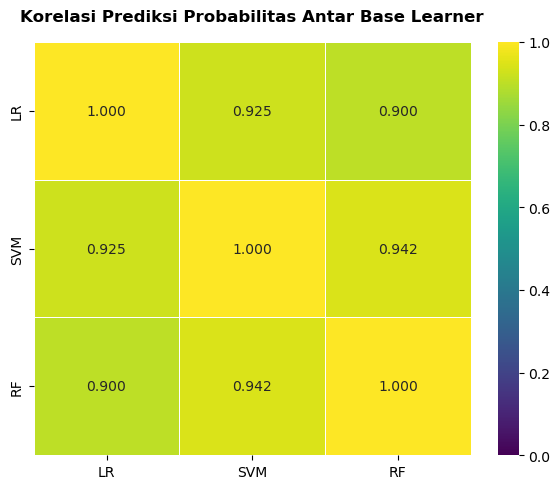

Kesimpulan Analisis Korelasi:
- Jika skor korelasi antar model rendah, berarti model belajar dari aspek/pola yang berbeda-beda.
- Ini memberikan meta-learner perspektif yang sangat kaya, sehingga Stacking bisa unggul jauh dibanding model tunggal.


In [3]:
# Ekstrak data yang sudah discaling & diseleksi fiturnya untuk simulasi OOF Plot
X_scaled = StandardScaler().fit_transform(X)
X_screened = lasso_selector.fit_transform(X_scaled, y)

print("Membuat Prediksi OOF dari masing-masing Base Learner (Inner CV = 10-fold)...")
oof_preds = {}
cv_inner = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in base_learners:
    # Mendapatkan probabilitas prediksi untuk kelas 1 (Success)
    preds = cross_val_predict(model, X_screened, y, cv=cv_inner, method='predict_proba', n_jobs=-1)[:, 1]
    oof_preds[name.upper()] = preds

df_oof = pd.DataFrame(oof_preds)

# Visualisasi Heatmap Korelasi Pearson
plt.figure(figsize=(6, 5))
sns.heatmap(df_oof.corr(), annot=True, cmap='viridis', vmin=0, vmax=1, fmt=".3f", linewidths=.5)
plt.title("Korelasi Prediksi Probabilitas Antar Base Learner", fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/stacking_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Kesimpulan Analisis Korelasi:")
print("- Jika skor korelasi antar model rendah, berarti model belajar dari aspek/pola yang berbeda-beda.")
print("- Ini memberikan meta-learner perspektif yang sangat kaya, sehingga Stacking bisa unggul jauh dibanding model tunggal.")